# Datos Cargados

In [1]:
from pyspark.sql import SparkSession
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import when, col, avg, countDistinct
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("analitica") \
    .getOrCreate()

print("La sesión de Spark se ha iniciado correctamente.")

25/11/24 20:15:37 WARN Utils: Your hostname, Proyecto-BigData resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
25/11/24 20:15:37 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/24 20:15:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/24 20:15:39 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


La sesión de Spark se ha iniciado correctamente.


In [2]:
catalogo_filtrado      = spark.table("gold.catalogo_filtrado")
items_filtrado         = spark.table("gold.items_filtrado")
transacciones_filtrado = spark.table("gold.transacciones_filtrado")
usuarios_filtrado      = spark.table("gold.usuarios_filtrado")

In [3]:
# Agregar columna homogenizada de categoría
catalogo_filtrado = catalogo_filtrado.withColumn(
    "categoria_general",
    when(col("categoria").rlike("(?i)infantil|ninos|niños"), "Infantil")
    .when(col("categoria").rlike("(?i)juvenil"), "Juvenil")
    .when(col("categoria").rlike("(?i)ficcion|ficción|narrativa|novela|literatura"), "Ficción")
    .when(col("categoria").rlike("(?i)no ficcion|no ficción|biografia|humanidades|historia|ensayo|filosofia|actualidad|politica|psicologia|sociologia"), "No ficción")
    .when(col("categoria").rlike("(?i)idiomas|ingles|espanol|portugues|aleman|italiano|frances"), "Idiomas")
    .when(col("categoria").rlike("(?i)comics|manga|novela grafica|marvel|dc"), "Cómics / Manga")
    .when(col("categoria").rlike("(?i)empresa|management|negocios|marketing|ventas|finanzas|recursos humanos|economia"), "Negocios")
    .when(col("categoria").rlike("(?i)profesional|tecnico|educacion|medicina|ingenieria|arquitectura|logistica|contabilidad|psicologia"), "Profesional / Técnico")
    .when(col("categoria").rlike("(?i)autoayuda|desarrollo personal|bienestar|mindfulness|espiritualidad|meditacion"), "Desarrollo personal")
    .when(col("categoria").rlike("(?i)hogar|manualidades|jardineria|cocina|viajes|maternidad|padres|vida"), "Vida y hogar")
    .when(col("categoria").rlike("(?i)juego|rompecabezas|complementos|smart play"), "Entretenimiento / Juegos")
    .otherwise("Otros")
)

catalogo_filtrado.select("categoria", "categoria_general", "vendor").sample(0.01, seed=42).show(10, truncate=False)

+---------------------------------------------+------------------------+------+
|categoria                                    |categoria_general       |vendor|
+---------------------------------------------+------------------------+------+
|Smart Play / Smart Play / Juguetes Educativos|Entretenimiento / Juegos|crisol|
|Ficcion / Mangas                             |Ficción                 |crisol|
|Ficcion / Mangas                             |Ficción                 |crisol|
|Ficcion                                      |Ficción                 |crisol|
|Infantil                                     |Infantil                |crisol|
|No Ficcion / Humanidades                     |Ficción                 |crisol|
|Ficcion                                      |Ficción                 |crisol|
|Ficcion / Mangas                             |Ficción                 |crisol|
|No Ficcion / Humanidades                     |Ficción                 |crisol|
|No Ficcion                             

# PARTE 1: Análisis Exploratorio de Datos

## 1.1 Conteo de registros por dataset

In [4]:
print("Conteo general de registros:")
print("Catálogo:", catalogo_filtrado.count())
print("Items:", items_filtrado.count())
print("Transacciones:", transacciones_filtrado.count())
print("Usuarios:", usuarios_filtrado.count())

Conteo general de registros:
Catálogo: 33985
Items: 267524
Transacciones: 107340
Usuarios: 11858


## 1.2 Distribución de precios

### SBS - Análisis Interno

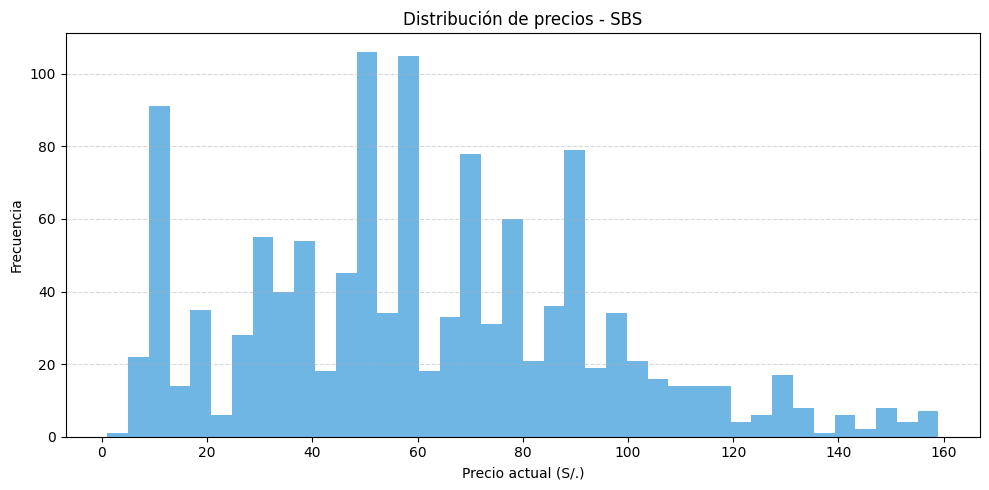

In [5]:
df_sbs_precios = catalogo_filtrado \
    .filter((col("vendor") == "sbs") & (col("precio_actual").isNotNull())) \
    .select("precio_actual") \
    .sample(0.05, seed=42) \
    .toPandas()

plt.figure(figsize=(10, 5))
plt.hist(df_sbs_precios["precio_actual"], bins=40, color="#3498db", alpha=0.7)
plt.title("Distribución de precios - SBS")
plt.xlabel("Precio actual (S/.)")
plt.ylabel("Frecuencia")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Comparación

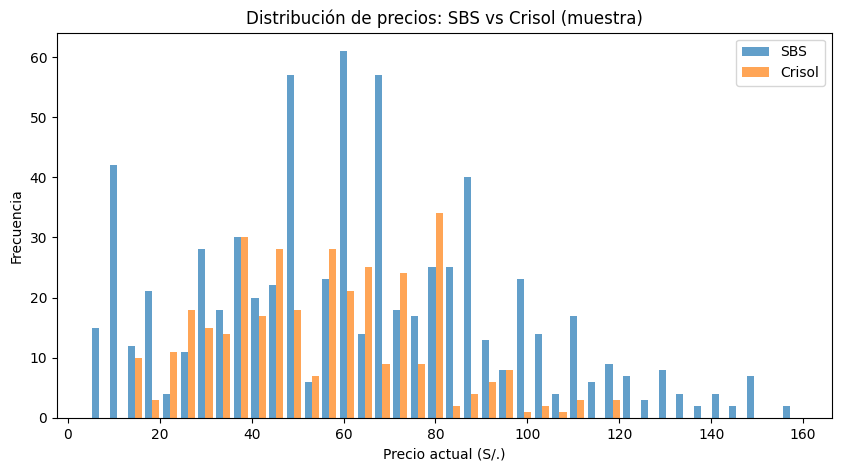

In [6]:
df_cat = catalogo_filtrado \
    .select("vendor", "precio_actual") \
    .where("precio_actual IS NOT NULL") \
    .sample(0.03, seed=42) \
    .toPandas()

plt.figure(figsize=(10,5))
plt.hist(
    [df_cat[df_cat.vendor == 'sbs'].precio_actual,
     df_cat[df_cat.vendor == 'crisol'].precio_actual],
    bins=40, alpha=0.7, label=['SBS', 'Crisol']
)
plt.legend()
plt.title("Distribución de precios: SBS vs Crisol (muestra)")
plt.xlabel("Precio actual (S/.)")
plt.ylabel("Frecuencia")
plt.show()

## 1.3 Precio promedio por categoría por vendor

### Análisis Interno SBS

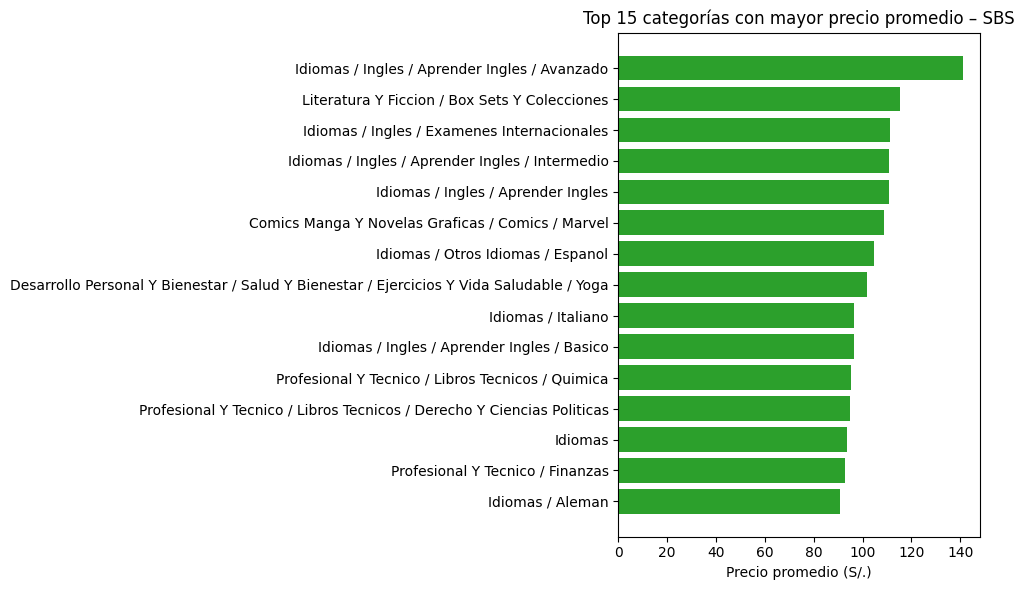

In [7]:
from pyspark.sql.functions import avg
import matplotlib.pyplot as plt

catalogo_sbs = catalogo_filtrado.filter(col("vendor") == "sbs")

# Calcular precio promedio por categoría
precio_categoria_sbs = catalogo_sbs.groupBy("categoria") \
    .agg(avg("precio_actual").alias("precio_promedio"))

df_precio_sbs = precio_categoria_sbs.toPandas()

top_precio_sbs = df_precio_sbs.sort_values("precio_promedio", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_precio_sbs["categoria"], top_precio_sbs["precio_promedio"], color="#2ca02c")
plt.title("Top 15 categorías con mayor precio promedio – SBS")
plt.xlabel("Precio promedio (S/.)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Comparación

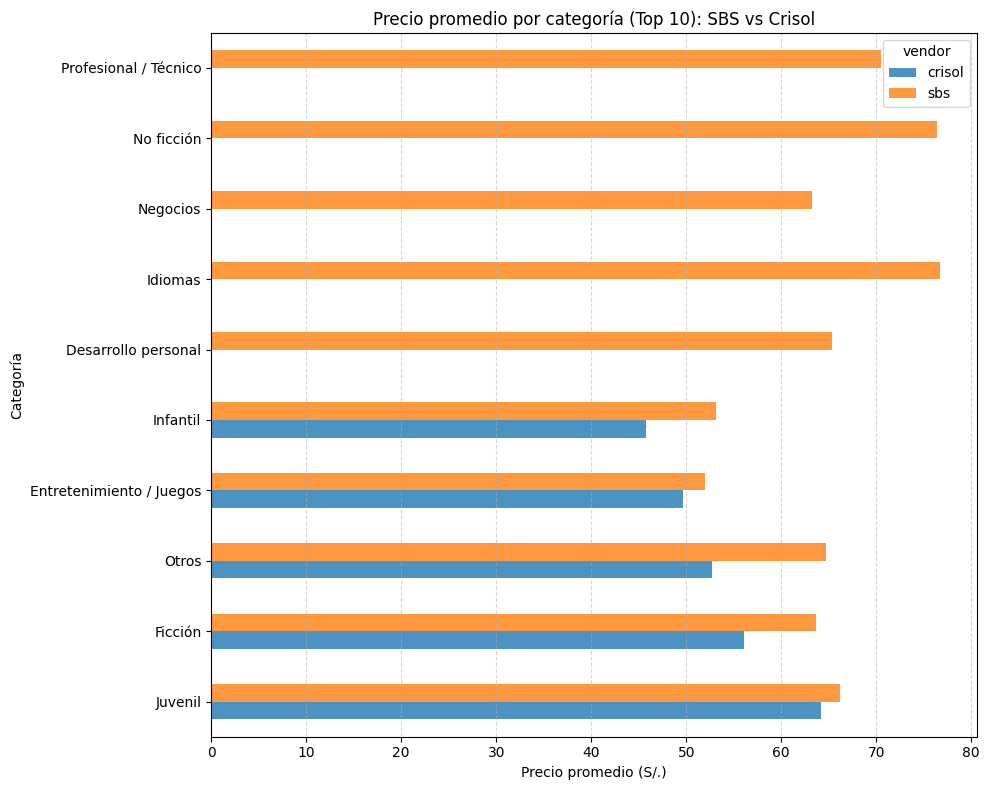

In [8]:
# Agrupamos precios por categoría y vendor
precio_categoria = catalogo_filtrado.groupBy("categoria_general", "vendor") \
    .agg(avg("precio_actual").alias("precio_promedio"))

df_precio_cat = precio_categoria.toPandas()

# Comparar categorías entre vendors
pivot = df_precio_cat.pivot(index="categoria_general", columns="vendor", values="precio_promedio").fillna(0)

# Ordenar por Crisol y seleccionar top 20
pivot = pivot.sort_values(by="crisol", ascending=False).head(20)

pivot.plot(kind="barh", figsize=(10, 8), alpha=0.8)
plt.xlabel("Precio promedio (S/.)")
plt.ylabel("Categoría")
plt.title("Precio promedio por categoría (Top 10): SBS vs Crisol")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 1.4 Descuento promedio por categoría

### Análisis Interno SBS

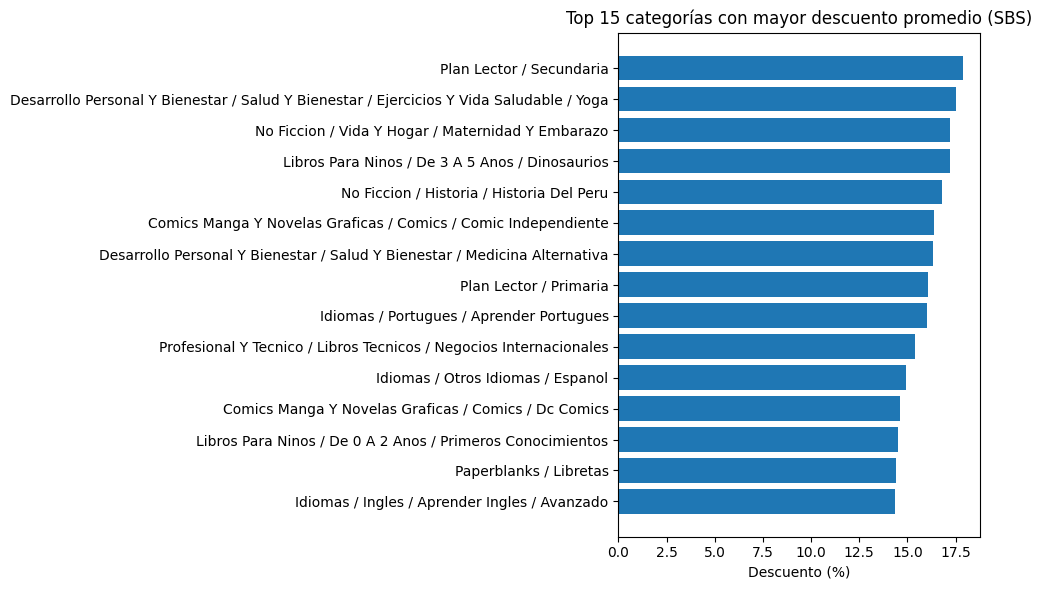

In [9]:
items_sbs = items_filtrado.filter(col("vendor") == "sbs")
catalogo_sbs = catalogo_filtrado.filter(col("vendor") == "sbs")

items_cat_sbs = items_sbs.join(
    catalogo_sbs.select("titulo", "categoria"),
    on="titulo",
    how="left"
)

# Calcular descuento promedio por categoría
descuento_categoria_sbs = items_cat_sbs.groupBy("categoria") \
    .agg(avg("descuento_aplicado_pct").alias("descuento_promedio"))

df_desc_sbs = descuento_categoria_sbs.toPandas()
top_desc_sbs = df_desc_sbs.sort_values("descuento_promedio", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_desc_sbs["categoria"], top_desc_sbs["descuento_promedio"], color="#1f77b4")
plt.title("Top 15 categorías con mayor descuento promedio (SBS)")
plt.xlabel("Descuento (%)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Comparación

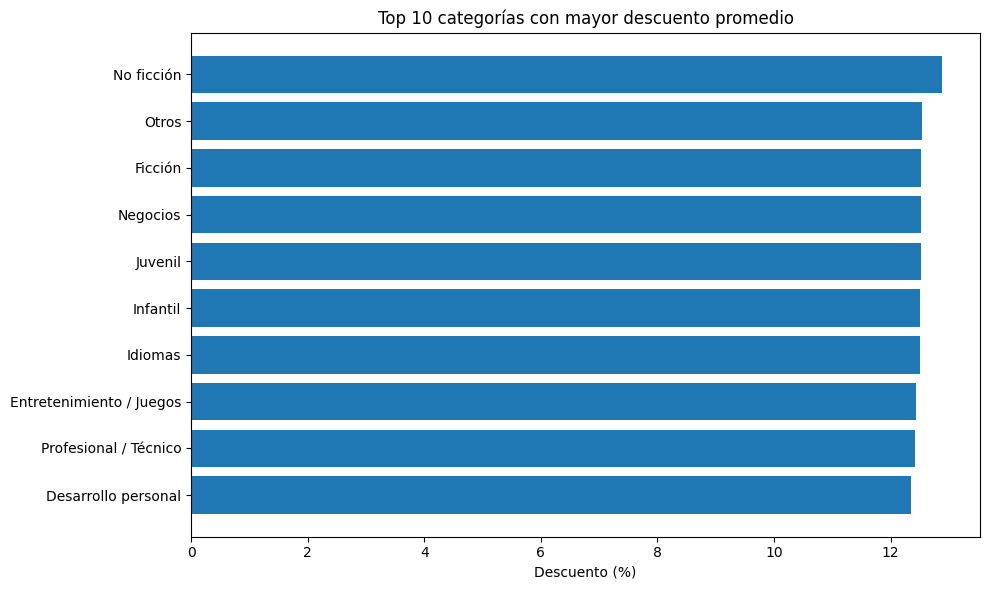

In [10]:
items_cat = items_filtrado.join(
    catalogo_filtrado.select("titulo", "categoria_general", "vendor"),
    on=["titulo", "vendor"],
    how="left"
)

# Agrupar por categoría y calcular descuento promedio
descuento_categoria = items_cat.groupBy("categoria_general") \
    .agg(avg("descuento_aplicado_pct").alias("descuento_promedio"))

df_desc = descuento_categoria.toPandas()
df_desc = df_desc[df_desc["categoria_general"].notna()]
top_desc = df_desc.sort_values("descuento_promedio", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_desc["categoria_general"], top_desc["descuento_promedio"], color="#1f77b4")
plt.title("Top 10 categorías con mayor descuento promedio")
plt.xlabel("Descuento (%)")
plt.gca().invert_yaxis()  # categoría con mayor descuento arriba
plt.tight_layout()
plt.show()

## 1.5 Surtido / productos únicos por vendor

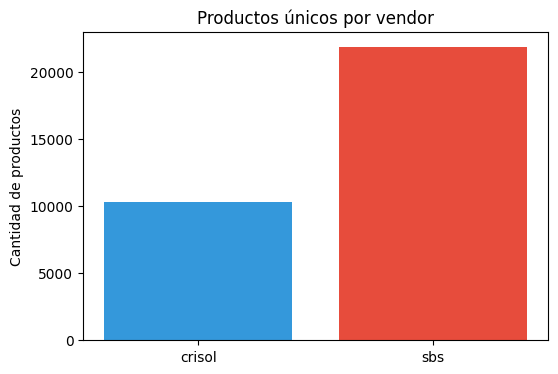

In [11]:
surtido = catalogo_filtrado.groupBy("vendor") \
    .agg(countDistinct("titulo").alias("productos_unicos"))

df_surtido = surtido.toPandas()

plt.figure(figsize=(6,4))
plt.bar(df_surtido["vendor"], df_surtido["productos_unicos"], color=["#3498db", "#e74c3c"])
plt.title("Productos únicos por vendor")
plt.ylabel("Cantidad de productos")
plt.show()

## 1.6 KPIs preliminares para alertas automáticas

### Análisis Interno SBS

Top 10 categorías con mayor precio promedio (SBS):
+--------------------+------------------+
|           categoria|   precio_promedio|
+--------------------+------------------+
|Idiomas / Ingles ...|             141.0|
|Literatura Y Ficc...|115.10684210526314|
|Idiomas / Ingles ...|111.22142857142856|
|Idiomas / Ingles ...|110.95714285714286|
|Idiomas / Ingles ...|110.59507389162563|
|Comics Manga Y No...|            108.75|
|Idiomas / Otros I...|104.78666666666668|
|Desarrollo Person...|             101.7|
|  Idiomas / Italiano|           96.4625|
|Idiomas / Ingles ...| 96.31900826446281|
+--------------------+------------------+
only showing top 10 rows



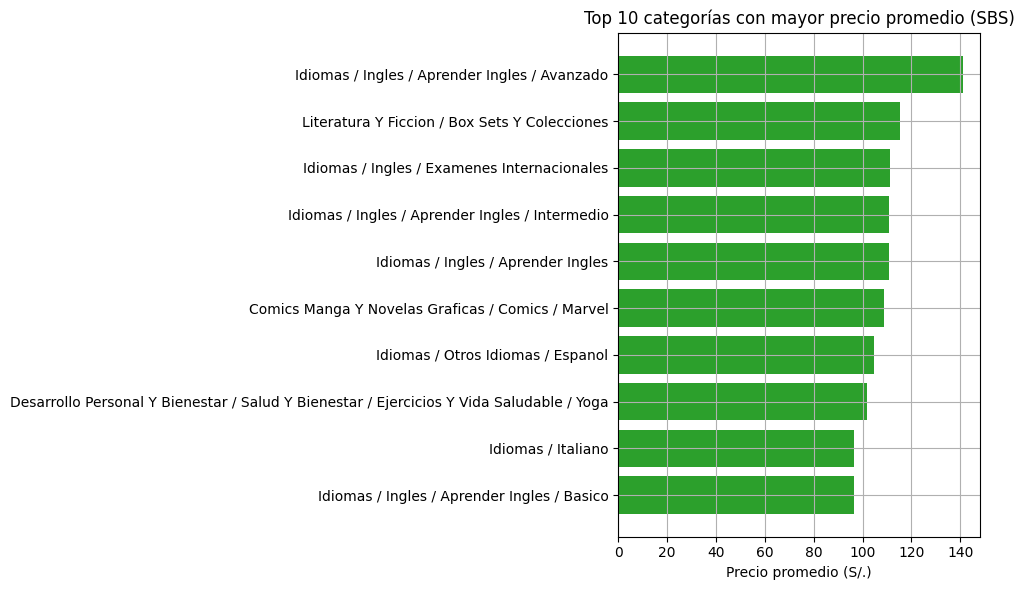

Top 10 categorías con mayor descuento promedio (SBS):
+--------------------+------------------+
|           categoria|descuento_promedio|
+--------------------+------------------+
|Plan Lector / Sec...|            17.875|
|Desarrollo Person...|              17.5|
|Libros Para Ninos...|              17.2|
|No Ficcion / Vida...|              17.2|
|No Ficcion / Hist...|              16.8|
|Comics Manga Y No...|              16.4|
|Desarrollo Person...|16.333333333333332|
|Plan Lector / Pri...|16.076923076923077|
|Idiomas / Portugu...|              16.0|
|Profesional Y Tec...|            15.375|
+--------------------+------------------+
only showing top 10 rows



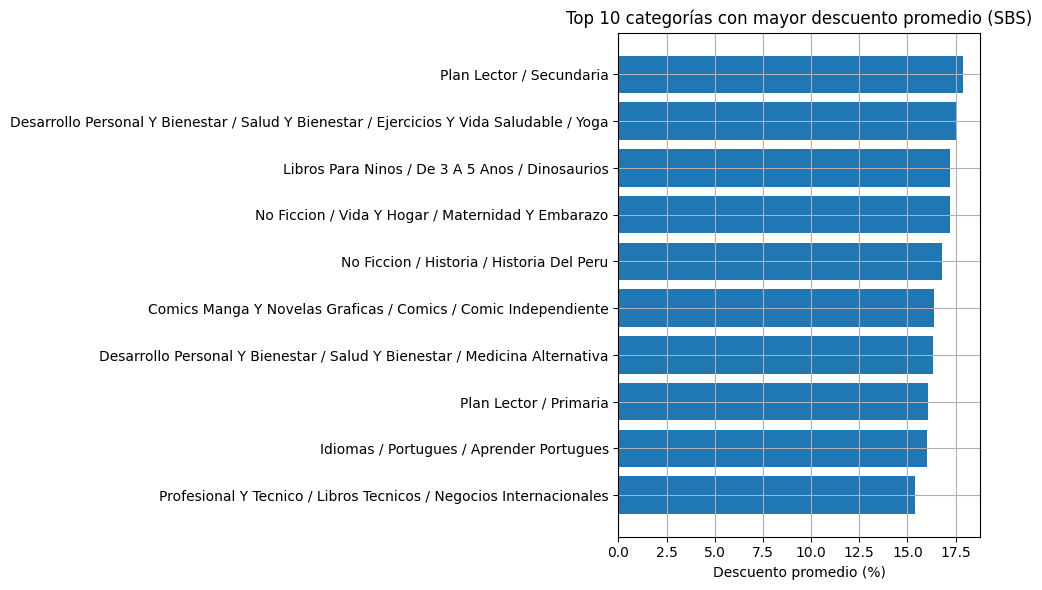

Top 10 libros más vendidos (SBS):
+--------------------+--------------+
|              titulo|cantidad_total|
+--------------------+--------------+
|LIBRETA TAPA BLAN...|            31|
|    ELVIS  (ESTUCHE)|            29|
|HEROINAS PERUANAS...|            28|
|INUYASHIKI (HOLOG...|            28|
|    UN NIÑO MUY RARO|            28|
|   EL DON DE TU ALMA|            27|
|ENGLISH CODE AMER...|            27|
|HARRY POTTER COLL...|            27|
|    ZOMBIE SUPERSTAR|            27|
|Collins Big Cat I...|            27|
+--------------------+--------------+
only showing top 10 rows



In [12]:
# Filtrar solo datos de SBS
catalogo_sbs = catalogo_filtrado.filter(col("vendor") == "sbs")
items_sbs = items_filtrado.filter(col("vendor") == "sbs")

# Precio promedio por categoría
precio_sbs = catalogo_sbs.groupBy("categoria") \
    .agg(F.avg("precio_actual").alias("precio_promedio")) \
    .orderBy(col("precio_promedio").desc())

print("Top 10 categorías con mayor precio promedio (SBS):")
precio_sbs.show(10)

df_precio_sbs = precio_sbs.limit(10).toPandas()
plt.figure(figsize=(10,6))
plt.barh(df_precio_sbs["categoria"], df_precio_sbs["precio_promedio"], color="#2ca02c")
plt.xlabel("Precio promedio (S/.)")
plt.title("Top 10 categorías con mayor precio promedio (SBS)")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

# Descuento promedio por categoría
items_cat_sbs = items_sbs.join(
    catalogo_sbs.select("titulo", "categoria"),
    on="titulo", how="left"
)

desc_sbs = items_cat_sbs.groupBy("categoria") \
    .agg(F.avg("descuento_aplicado_pct").alias("descuento_promedio")) \
    .orderBy(col("descuento_promedio").desc())

print("Top 10 categorías con mayor descuento promedio (SBS):")
desc_sbs.show(10)

df_desc_sbs = desc_sbs.limit(10).toPandas()
plt.figure(figsize=(10,6))
plt.barh(df_desc_sbs["categoria"], df_desc_sbs["descuento_promedio"], color="#1f77b4")
plt.xlabel("Descuento promedio (%)")
plt.title("Top 10 categorías con mayor descuento promedio (SBS)")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

# Libros más vendidos por cantidad (interna)
ventas_sbs = items_sbs.groupBy("titulo") \
    .agg(F.sum("cantidad").alias("cantidad_total")) \
    .orderBy(col("cantidad_total").desc())

print("Top 10 libros más vendidos (SBS):")
ventas_sbs.show(10)

### Comparación

Top 10 categorías con mayor brecha de precios:
+--------------------+------------------+-----------------+-------------------+
|   categoria_general|            crisol|              sbs|         brecha_pct|
+--------------------+------------------+-----------------+-------------------+
|             Juvenil|  64.1524907063191| 66.1814597060316|-3.0657664680182157|
|Entretenimiento /...|49.692386018237386|52.01107692307693| -4.458071322516216|
|             Ficción| 56.08543019135528|63.64649779249388|-11.879785790869256|
|            Infantil|45.776245791245515|53.10313946083619|-13.797477407139539|
|               Otros| 52.72430379746831|64.74839848675914|-18.570489726861318|
+--------------------+------------------+-----------------+-------------------+



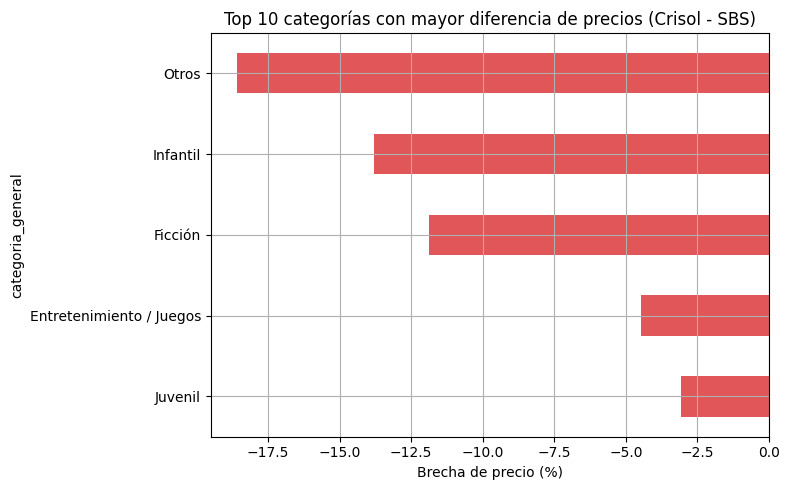

Descuento promedio por vendor:
+------+------------------+
|vendor|descuento_promedio|
+------+------------------+
|   sbs|12.497444066907976|
|crisol|12.498838680551017|
+------+------------------+

Top 10 libros con más ventas (cantidad):


[Stage 75:>                                                         (0 + 4) / 4]

+--------------------+--------------+
|              titulo|cantidad_total|
+--------------------+--------------+
|                1984|           326|
|Harry Potter y la...|           235|
|El arte de la guerra|           219|
|Harry Potter y la...|           216|
|       El principito|           208|
|Harry Potter y el...|           198|
|      Fahrenheit 451|           197|
|        Frankenstein|           192|
|Harry Potter y el...|           187|
|           Jane Eyre|           185|
+--------------------+--------------+
only showing top 10 rows



In [13]:
# Brecha de precios por categoría
dif_precio = catalogo_filtrado.groupBy("categoria_general") \
    .pivot("vendor") \
    .agg(F.avg("precio_actual")) \
    .withColumn("brecha_pct", ((col("crisol") - col("sbs")) / col("sbs")) * 100)

# Filtramos solo donde ambos vendors existen para evitar NULL
dif_precio_filtrado = dif_precio.filter(
    col("crisol").isNotNull() & col("sbs").isNotNull()
)

print("Top 10 categorías con mayor brecha de precios:")
dif_precio_filtrado.orderBy(col("brecha_pct").desc()).show(10)

df_kpi = dif_precio_filtrado.select("categoria_general", "brecha_pct").toPandas()
df_kpi.sort_values(by="brecha_pct", ascending=False).head(10).plot(
    kind='barh', x='categoria_general', y='brecha_pct', figsize=(8, 5),
    color='#e15759', legend=False)
plt.xlabel('Brecha de precio (%)')
plt.title('Top 10 categorías con mayor diferencia de precios (Crisol - SBS)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Descuento promedio por vendor
desc_vendor = items_filtrado.groupBy("vendor") \
    .agg(F.avg("descuento_aplicado_pct").alias("descuento_promedio"))

print("Descuento promedio por vendor:")
desc_vendor.show()

# Incremento de volumen por título
volumen_categoria = items_filtrado.groupBy("titulo") \
    .agg(F.sum("cantidad").alias("cantidad_total"))

print("Top 10 libros con más ventas (cantidad):")
volumen_categoria.orderBy(col("cantidad_total").desc()).show(10)

Se realizó una exploración descriptiva completa de la oferta de productos y comportamiento de ventas internas simuladas del vendor SBS, así como una comparación con Crisol en variables clave como precio, descuento y surtido. Esta base permitirá en la Parte 2 profundizar en indicadores comerciales estratégicos, segmentación de clientes y generación de alertas automáticas.

# PARTE 2: Modelos Analíticos para Indicadores del Proyecto

## Indicador Comparación de estrategias competitivas

In [14]:
spark.table("gold.items_filtrado").columns


['transaction_id',
 'titulo',
 'cantidad',
 'precio_unitario',
 'descuento_aplicado_pct',
 'precio_final_unitario',
 'vendor']

## Indicador Anticipación de promociones

In [15]:
# Notebook: Indicador Anticipación de Promociones (versión corregida, leakage-free)
# Requiere PySpark 3.0+ (probado en 3.5.x)
# --------------------------------------------------

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, lit, when, expr, date_trunc, coalesce
from pyspark.sql.types import DoubleType, DateType
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from functools import reduce
import math

In [16]:
# -------------------------
# Config
# -------------------------
VENDOR = "sbs"
DISCOUNT_THRESHOLD = 20.0   # pct threshold to call a week "discounted"
PRED_WINDOW_DAYS = 90       # future window to label
SNAPSHOT_DATES = ["2025-01-01","2025-04-01","2025-07-01"]
TEST_CUTOFF = "2025-07-01"
MIN_WEEKS_FOR_ELAST = 3
EPS = 1e-6
RECENT_WEEKS = 8
RANDOM_SEED = 42

In [17]:
# -------------------------
# 0) Cargar tablas gold (asegúrate que los nombres existan)
# -------------------------
catalog = (
    spark.table("gold.catalogo_filtrado")
         .filter(col("vendor") == VENDOR)
         .select("titulo", "precio_actual", "categoria", "editorial")
         .withColumn("precio_actual", col("precio_actual").cast(DoubleType()))
)

items = (
    spark.table("gold.items_filtrado")
         .filter(col("vendor") == VENDOR)
         .withColumn("cantidad", col("cantidad").cast("long"))
         .withColumn("precio_unitario", col("precio_unitario").cast(DoubleType()))
         .withColumn("descuento_aplicado_pct", col("descuento_aplicado_pct").cast(DoubleType()))
)

tx = (
    spark.table("gold.transacciones_filtrado")
         .filter(col("vendor") == VENDOR)
         .withColumn("fecha_compra", F.to_date(col("fecha_compra")))
         .select("transaction_id", "fecha_compra")
)

# unir items con fecha (left join manteniendo items)
items = items.alias("i").join(tx.alias("t"), "transaction_id", "left").select("i.*", "t.fecha_compra")


In [18]:
# -------------------------
# Helper: función que construye snapshot SIN leakage
# -------------------------
def build_snapshot(cutoff_str):
    cutoff = F.to_date(lit(cutoff_str))
    future_end = F.date_add(cutoff, PRED_WINDOW_DAYS)

    # 1) histórico solo antes del cutoff
    hist = items.filter(col("fecha_compra") < cutoff)
    if hist.rdd.isEmpty():
        return hist.limit(0)

    # 2) weekly (por título)
    weekly = (
        hist.withColumn("week_start", date_trunc("week", col("fecha_compra")).cast(DateType()))
            .groupBy("titulo", "week_start")
            .agg(
                F.sum("cantidad").alias("qty_week"),
                (F.sum(col("precio_unitario") * col("cantidad")) / F.greatest(F.sum("cantidad"), lit(1))).alias("avg_price_week"),
                F.avg("descuento_aplicado_pct").alias("avg_discount_week"),
                F.countDistinct("transaction_id").alias("tx_count_week"),
                F.sum(when(col("descuento_aplicado_pct") >= DISCOUNT_THRESHOLD, 1).otherwise(0)).alias("discount_weeks_flag_raw")
            )
    )

    weekly = weekly.withColumn("qty_week", col("qty_week").cast(DoubleType()))
    weekly = weekly.withColumn("log_qty", F.log(col("qty_week") + EPS))
    weekly = weekly.withColumn("log_price", F.log(col("avg_price_week") + EPS))
    weekly = weekly.withColumn("is_disc", when(col("avg_discount_week") >= DISCOUNT_THRESHOLD, 1).otherwise(0))

    # 3) agregados por título
    agg = weekly.groupBy("titulo").agg(
        F.count("*").alias("n_weeks"),
        F.sum("log_price").alias("sum_logp"),
        F.sum("log_qty").alias("sum_logq"),
        F.sum(col("log_price") * col("log_qty")).alias("sum_logp_logq"),
        F.sum(col("log_price") * col("log_price")).alias("sum_logp2"),
        F.stddev_pop("avg_price_week").alias("std_price"),
        F.avg("avg_price_week").alias("avg_price"),
        F.sum("qty_week").alias("total_qty"),
        F.sum("is_disc").alias("count_discount_weeks")
    )

    elast = agg.withColumn(
        "elasticity_raw",
        ((col("n_weeks") * col("sum_logp_logq") - col("sum_logp") * col("sum_logq")) /
         F.greatest((col("n_weeks") * col("sum_logp2") - col("sum_logp") * col("sum_logp")), lit(1e-9)))
    ).withColumn(
        "elasticity",
        when((col("n_weeks") >= MIN_WEEKS_FOR_ELAST) & (col("std_price") > 0.0001), col("elasticity_raw")).otherwise(None)
    )

    # 5) lift
    disc = weekly.groupBy("titulo").agg(
        F.avg(when(col("is_disc") == 1, col("qty_week"))).alias("avg_qty_disc"),
        F.avg(when(col("is_disc") == 0, col("qty_week"))).alias("avg_qty_nodisc"),
        F.sum("is_disc").alias("num_disc_weeks"),
        F.count("*").alias("num_weeks")
    ).withColumn("lift_after_discount", col("avg_qty_disc") / F.greatest(col("avg_qty_nodisc"), lit(1.0)))

    # 6) trend
    w_desc = Window.partitionBy("titulo").orderBy(col("week_start").desc())
    recent = weekly.withColumn("rn", F.row_number().over(w_desc)).filter(col("rn") <= RECENT_WEEKS)
    trend = recent.groupBy("titulo").agg(
        F.count("*").alias("n_r"),
        F.sum("rn").alias("sum_x"),
        F.sum("qty_week").alias("sum_y"),
        F.sum(col("rn") * col("qty_week")).alias("sum_xy"),
        F.sum(col("rn") * col("rn")).alias("sum_x2")
    ).withColumn(
        "trend_slope",
        ((col("n_r") * col("sum_xy") - col("sum_x") * col("sum_y")) /
         F.greatest((col("n_r") * col("sum_x2") - col("sum_x") * col("sum_x")), lit(1e-9)))
    )

    # 7) recency
    last_disc = weekly.filter(col("avg_discount_week") >= DISCOUNT_THRESHOLD) \
                      .groupBy("titulo").agg(F.max("week_start").alias("last_discount_week"))

    # 8) unir features
    feat = elast.join(disc.select("titulo","avg_qty_disc","avg_qty_nodisc","num_disc_weeks","num_weeks","lift_after_discount"), "titulo", "left") \
               .join(trend.select("titulo","trend_slope"), "titulo", "left") \
               .join(last_disc, "titulo", "left")

    # 9) unir catálogo
    snap = feat.join(catalog.withColumnRenamed("precio_actual","precio_actual_catalog"), "titulo", "left") \
               .withColumn("snapshot_date", cutoff)
    
    # 10) derivadas
    snap = snap.withColumn("days_since_last_discount", 
                           when(col("last_discount_week").isNull(), lit(9999))
                           .otherwise(F.datediff(cutoff, col("last_discount_week"))))
    
    # pct_times_discounted (porcentaje de semanas con descuento históricas)
    snap = snap.withColumn("pct_times_discounted", 
                           (col("num_disc_weeks") / F.greatest(col("num_weeks"), lit(1))) * 100.0)
    
    # --- ahora sí podemos crear elasticity_proxy ---
    snap = snap.withColumn(
        "elasticity_proxy",
        when(col("elasticity").isNotNull(), col("elasticity"))
        .otherwise(col("pct_times_discounted") / F.greatest(col("num_weeks"), lit(1)))
    )
    # 11) etiqueta futura
    fut = items.filter((col("fecha_compra") >= cutoff) & (col("fecha_compra") <= future_end))
    lab = fut.groupBy("titulo").agg(F.max(when(col("descuento_aplicado_pct") >= DISCOUNT_THRESHOLD, 1).otherwise(0)).alias("label_discount_next_window"))
    snap = snap.join(lab, "titulo", "left").fillna({"label_discount_next_window": 0})

    # 12) temporales
    snap = snap.withColumn("month", F.month(cutoff)).withColumn("quarter", F.quarter(cutoff))

    # 13) imputaciones seguras y tipos
    snap = snap.fillna({
        "lift_after_discount": 0.0,
        "trend_slope": 0.0,
        "std_price": 0.0,
        "total_qty": 0.0,
        "avg_price": 0.0,
        "num_weeks": 0,
        "num_disc_weeks": 0,
        "categoria": "UNKNOWN",
        "editorial": "UNKNOWN"
    })

    numeric_cols = ["avg_price","total_qty","std_price","lift_after_discount","trend_slope",
                    "days_since_last_discount","pct_times_discounted","num_weeks","num_disc_weeks","count_discount_weeks","elasticity_proxy"]
    for c in numeric_cols:
        if c in snap.columns:
            snap = snap.withColumn(c, coalesce(col(c).cast(DoubleType()), lit(0.0)))

    return snap

In [19]:
# -------------------------
# Construir snapshots y concatenar
# -------------------------
snapshots = [build_snapshot(d) for d in SNAPSHOT_DATES]
# filter out empty DataFrames (if any snapshot returned empty)
snapshots = [s for s in snapshots if not s.rdd.isEmpty()]
df_all = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), snapshots)

# cache
df_all = df_all.cache()
print("Total rows (all snapshots):", df_all.count())


25/11/24 20:17:40 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 266:====================================================>(599 + 1) / 600]

Total rows (all snapshots): 70837


In [20]:
df_all.select("lift_after_discount").describe().show()
df_all.select("trend_slope").describe().show()

+-------+-------------------+
|summary|lift_after_discount|
+-------+-------------------+
|  count|              70837|
|   mean| 0.6094108811629563|
| stddev|   0.76525411044487|
|    min|                0.0|
|    max|                6.0|
+-------+-------------------+



[Stage 296:=================================================>   (564 + 6) / 600]

+-------+--------------------+
|summary|         trend_slope|
+-------+--------------------+
|  count|               70837|
|   mean|-0.00196551170124...|
| stddev|  0.6827347758654544|
|    min|                -5.0|
|    max|                 6.0|
+-------+--------------------+



In [21]:
# -------------------------
# Quick diagnostics: label distribution and some stats
# -------------------------
df_all.groupBy("label_discount_next_window").count().show()
df_all.select("snapshot_date").distinct().show()
df_all.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in ["elasticity","avg_price","pct_times_discounted"]]).show()
df_all.select("avg_price","total_qty","pct_times_discounted").describe().show()

+--------------------------+-----+
|label_discount_next_window|count|
+--------------------------+-----+
|                         1| 7760|
|                         0|63077|
+--------------------------+-----+



+-------------+
|snapshot_date|
+-------------+
|   2025-01-01|
|   2025-04-01|
|   2025-07-01|
+-------------+



+----------+---------+--------------------+
|elasticity|avg_price|pct_times_discounted|
+----------+---------+--------------------+
|     70837|        0|                   0|
+----------+---------+--------------------+



[Stage 356:====================================================>(595 + 5) / 600]

+-------+-----------------+-----------------+--------------------+
|summary|        avg_price|        total_qty|pct_times_discounted|
+-------+-----------------+-----------------+--------------------+
|  count|            70837|            70837|               70837|
|   mean|74.85497113090607|6.634033061817976|  21.889276177218903|
| stddev|62.14558093050126|3.779517392951533|   26.97757639533778|
|    min|              1.0|              1.0|                 0.0|
|    max|           1299.4|             31.0|               100.0|
+-------+-----------------+-----------------+--------------------+



In [22]:
df_all.selectExpr(
    "count(elasticity) as n_with_elast",
    "count(*) as total",
    "sum(case when elasticity is null then 1 else 0 end) as nulls",
    "sum(case when elasticity = 0 then 1 else 0 end) as zeros",
    "sum(case when elasticity < 0 then 1 else 0 end) as negative"
).show()

[Stage 371:=================================================>  (575 + 11) / 600]

+------------+-----+-----+-----+--------+
|n_with_elast|total|nulls|zeros|negative|
+------------+-----+-----+-----+--------+
|           0|70837|70837|    0|       0|
+------------+-----+-----+-----+--------+



In [23]:
# -------------------------
# 5) Train/test split (by snapshot date)
# -------------------------

df_all = df_all.withColumn(
    "discount_volume",
    col("pct_times_discounted") * col("total_qty") / F.lit(100.0)
)
train = df_all.filter(col("snapshot_date") < F.to_date(lit(TEST_CUTOFF)))
test  = df_all.filter(col("snapshot_date") >= F.to_date(lit(TEST_CUTOFF)))

print("Train rows:", train.count(), "Test rows:", test.count())


[Stage 401:===================================================> (587 + 7) / 600]

Train rows: 46728 Test rows: 24109


In [24]:
# -------------------------
# 6) Feature selection: drop constant / near-constant features automatically
# -------------------------
# Candidate features (start broad, then we'll drop constants)
candidate_feats = [
    "precio_actual_catalog", "avg_price", "total_qty", "std_price", "elasticity",
    "lift_after_discount", "trend_slope", "days_since_last_discount",
    "pct_times_discounted", "discount_volume", "month", "quarter", "num_weeks", "num_disc_weeks"
]

# compute stddev per candidate on train; drop features with stddev very small (near-constant)
stats = train.select([F.stddev_pop(c).alias(c + "_std") for c in candidate_feats]).collect()[0].asDict()
drop_feats = [k.replace("_std","") for k,v in stats.items() if v is None or v < 1e-6]
print("Dropping near-constant features:", drop_feats)

feat_cols = [c for c in candidate_feats if c not in drop_feats]
print("Final feature columns:", feat_cols)

# if elasticity present but mostly nulls, remove it
if "elasticity" in feat_cols:
    n_notnull_elast = train.filter(col("elasticity").isNotNull()).count()
    if n_notnull_elast < 50:  # heuristic threshold
        print("Too few non-null elasticity values (", n_notnull_elast,") -> removing elasticity from features")
        feat_cols.remove("elasticity")

# ensure discount_volume exists (calc from avg discount and total_qty)
if "discount_volume" in feat_cols and "discount_volume" not in df_all.columns:
    df_all = df_all.withColumn("discount_volume", col("pct_times_discounted") * col("total_qty") / lit(100.0))
    train = train.join(df_all.select("titulo","snapshot_date","discount_volume"), ["titulo","snapshot_date"], "left").select(df_all.columns)
    test = test.join(df_all.select("titulo","snapshot_date","discount_volume"), ["titulo","snapshot_date"], "left").select(df_all.columns)

[Stage 416:====================================================>(594 + 6) / 600]

Dropping near-constant features: ['std_price', 'elasticity']
Final feature columns: ['precio_actual_catalog', 'avg_price', 'total_qty', 'lift_after_discount', 'trend_slope', 'days_since_last_discount', 'pct_times_discounted', 'discount_volume', 'month', 'quarter', 'num_weeks', 'num_disc_weeks']


In [25]:

# -------------------------
# 7) Prepare train/test: handle nulls, categorical indexing, assembler
# -------------------------
# safe-impute numeric nulls in train/test
for c in feat_cols:
    train = train.withColumn(c, coalesce(col(c), lit(0.0)))
    test = test.withColumn(c, coalesce(col(c), lit(0.0)))

# categorical indexers
idx_cat = StringIndexer(inputCol="categoria", outputCol="categoria_idx", handleInvalid="keep")
idx_edit = StringIndexer(inputCol="editorial", outputCol="editorial_idx", handleInvalid="keep")

# Assembler inputs: numeric features + categorical indices
assembler_inputs = feat_cols + ["categoria_idx", "editorial_idx"]

assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="raw_features", handleInvalid="keep")

# StandardScaler (do not use withMean=True if data is sparse or pipeline heavy; safer withMean=False)
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withMean=False, withStd=True)


In [26]:
# -------------------------
# 8) Balanceo: undersample negatives to target ratio (done on train)
# -------------------------
count_pos = train.filter(col("label_discount_next_window")==1).count()
count_neg = train.filter(col("label_discount_next_window")==0).count()
print("Before balancing pos/neg:", count_pos, count_neg)

target_ratio = 3.0
if count_pos == 0:
    train_bal = train
else:
    frac_neg = min(1.0, (count_pos * target_ratio) / max(1, count_neg))
    neg_sample = train.filter(col("label_discount_next_window")==0).sample(False, frac_neg, seed=RANDOM_SEED)
    pos_sample = train.filter(col("label_discount_next_window")==1)
    train_bal = pos_sample.union(neg_sample)
print("After balancing rows:", train_bal.count())

Before balancing pos/neg: 5043 41685


[Stage 461:==================================================>(1184 + 7) / 1200]

After balancing rows: 20311


In [27]:

# -------------------------
# 9) Pipeline and training
# -------------------------
gbt = GBTClassifier(featuresCol="features", labelCol="label_discount_next_window", maxIter=50, seed=RANDOM_SEED)

pipeline = Pipeline(stages=[idx_cat, idx_edit, assembler, scaler, gbt])

# fit model
# Subsamplear para acelerar entrenamiento (≈ 10,000 filas)
train_bal = train_bal.sample(withReplacement=False, fraction=10000.0 / train_bal.count(), seed=RANDOM_SEED)
print("Usando para entrenamiento:", train_bal.count(), "filas.")
model = pipeline.fit(train_bal)


Usando para entrenamiento: 10021 filas.


25/11/24 20:58:51 WARN DAGScheduler: Broadcasting large task binary with size 1000.5 KiB
25/11/24 20:59:02 WARN DAGScheduler: Broadcasting large task binary with size 1003.2 KiB
25/11/24 20:59:13 WARN DAGScheduler: Broadcasting large task binary with size 1003.7 KiB
25/11/24 20:59:24 WARN DAGScheduler: Broadcasting large task binary with size 1004.4 KiB
25/11/24 20:59:33 WARN DAGScheduler: Broadcasting large task binary with size 1005.4 KiB
25/11/24 20:59:41 WARN DAGScheduler: Broadcasting large task binary with size 1007.7 KiB
25/11/24 20:59:50 WARN DAGScheduler: Broadcasting large task binary with size 1010.3 KiB
25/11/24 20:59:59 WARN DAGScheduler: Broadcasting large task binary with size 1010.8 KiB
25/11/24 21:00:07 WARN DAGScheduler: Broadcasting large task binary with size 1011.5 KiB
25/11/24 21:00:15 WARN DAGScheduler: Broadcasting large task binary with size 1012.5 KiB
25/11/24 21:00:24 WARN DAGScheduler: Broadcasting large task binary with size 1014.8 KiB
25/11/24 21:00:33 WAR

In [28]:
# -------------------------
# 10) Evaluación robusta
# -------------------------
pred = model.transform(test).cache()

# extract proba
pred = pred.withColumn("p_discount", vector_to_array("probability")[1])

# basic metrics: AUC (ROC), areaUnderPR
evaluator_roc = BinaryClassificationEvaluator(labelCol="label_discount_next_window", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_pr  = BinaryClassificationEvaluator(labelCol="label_discount_next_window", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

auc = evaluator_roc.evaluate(pred)
pr  = evaluator_pr.evaluate(pred)
print("AUC (ROC):", auc)
print("AreaUnderPR:", pr)

# Precision@K (top 5%)
k_frac = 0.05
q = pred.approxQuantile("p_discount", [1.0 - k_frac], 0.001)
threshold_k = q[0] if q else 1.0
topk = pred.filter(col("p_discount") >= lit(threshold_k))
topk_count = topk.count()
topk_pos = topk.filter(col("label_discount_next_window")==1).count()
precision_at_k = topk_pos / float(max(1, topk_count))
print(f"Precision@{int(k_frac*100)}%:", precision_at_k, "(topk rows:", topk_count, "pos:", topk_pos, ")")

# Confusion matrix at default threshold 0.5
pred_label = pred.withColumn("pred_label", when(col("p_discount") >= 0.5, 1).otherwise(0))
cm = pred_label.groupBy("label_discount_next_window", "pred_label").count().toPandas()
print("Confusion matrix (label vs pred at 0.5):")
print(cm)

# Feature importances
gbt_model = model.stages[-1]
try:
    fi = gbt_model.featureImportances.toArray().tolist()
    feat_names = assembler_inputs
    feat_imp = sorted(list(zip(feat_names, fi)), key=lambda x: -x[1])[:20]
    print("Top feature importances:")
    for f,imp in feat_imp:
        print(f, round(imp, 4))
except Exception as e:
    print("No feature importances available:", e)



25/11/24 21:39:00 WARN DAGScheduler: Broadcasting large task binary with size 1160.2 KiB
25/11/24 21:39:20 WARN DAGScheduler: Broadcasting large task binary with size 1174.0 KiB
25/11/24 21:39:54 WARN DAGScheduler: Broadcasting large task binary with size 1174.0 KiB
                                                                                

AUC (ROC): 0.49920314254497217
AreaUnderPR: 0.11439168284441184


25/11/24 21:40:27 WARN DAGScheduler: Broadcasting large task binary with size 1175.2 KiB
25/11/24 21:40:50 WARN DAGScheduler: Broadcasting large task binary with size 1176.3 KiB
25/11/24 21:40:52 WARN DAGScheduler: Broadcasting large task binary with size 1172.5 KiB
25/11/24 21:41:16 WARN DAGScheduler: Broadcasting large task binary with size 1172.9 KiB
                                                                                

Precision@5%: 0.12839506172839507 (topk rows: 1215 pos: 156 )


25/11/24 21:41:39 WARN DAGScheduler: Broadcasting large task binary with size 1179.6 KiB
[Stage 2697:===================================================>(589 + 8) / 600]

Confusion matrix (label vs pred at 0.5):
   label_discount_next_window  pred_label  count
0                           1           0   2674
1                           0           0  21096
2                           0           1    296
3                           1           1     43
Top feature importances:
editorial_idx 0.1351
categoria_idx 0.1331
trend_slope 0.1169
precio_actual_catalog 0.1054
total_qty 0.0887
avg_price 0.0867
days_since_last_discount 0.0784
lift_after_discount 0.077
pct_times_discounted 0.0539
discount_volume 0.0525
num_weeks 0.039
num_disc_weeks 0.0181
month 0.0152
quarter 0.0


25/11/24 21:41:59 WARN DAGScheduler: Broadcasting large task binary with size 1176.6 KiB
                                                                                

In [29]:
# Save predictions and model artifacts (opcional)
OUT = "/data/processed/parquet/ind2_promociones_elasticidad_sbs"
pred.select("titulo","snapshot_date","p_discount","prediction","label_discount_next_window").write.mode("overwrite").parquet(OUT)
print("[OK] Predicciones guardadas en:", OUT)

# -------------------------
# 11) Recomendaciones y next steps (resumen)
# -------------------------
print("\nRECOMENDACIONES INMEDIATAS:")
print("- Si AUC aún ~0.5: revisar distribution de las features top (stddev ~0 => feature plana).")
print("- Si elasticity está mayoritariamente NULL: ajustar MIN_WEEKS_FOR_ELAST a menor valor o mejorar granularidad temporal.")
print("- Considerar engineering adicional: seasonality features, competitor price, marketing calendar, windows de más snapshots.")
print("- Si positives muy raros: probar oversampling (SMOTE) o modelos calibrados + threshold tuning.")

25/11/24 21:46:01 WARN DAGScheduler: Broadcasting large task binary with size 1371.8 KiB
                                                                                

[OK] Predicciones guardadas en: /data/processed/parquet/ind2_promociones_elasticidad_sbs

RECOMENDACIONES INMEDIATAS:
- Si AUC aún ~0.5: revisar distribution de las features top (stddev ~0 => feature plana).
- Si elasticity está mayoritariamente NULL: ajustar MIN_WEEKS_FOR_ELAST a menor valor o mejorar granularidad temporal.
- Considerar engineering adicional: seasonality features, competitor price, marketing calendar, windows de más snapshots.
- Si positives muy raros: probar oversampling (SMOTE) o modelos calibrados + threshold tuning.


### Detección de fluctuaciones de precios

In [31]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

RANDOM_SEED = 42
TEST_SIZE = 0.2
RF_NUM_TREES = 70
VENDOR = "sbs"

In [33]:
# 1) Carga y casting

catalog = spark.table("gold.catalogo_filtrado").filter(col("vendor") == VENDOR).select(
"titulo", "precio_actual", "categoria", "editorial", "vendor"
).withColumn("precio_actual", col("precio_actual").cast("double"))

items = spark.table("gold.items_filtrado").filter(col("vendor") == VENDOR).select(
"transaction_id", "titulo", "cantidad", "precio_unitario", "descuento_aplicado_pct", "vendor"
).withColumn("descuento_aplicado_pct", col("descuento_aplicado_pct").cast("double")) \
.withColumn("cantidad", col("cantidad").cast("long"))

In [34]:
# 2) Agregados históricos

agg = items.groupBy("titulo", "vendor").agg(
F.countDistinct("transaction_id").alias("tx_count"),
F.sum("cantidad").alias("total_unidades_vendidas"),
F.avg("precio_unitario").alias("avg_price_hist"),
F.avg("descuento_aplicado_pct").alias("avg_discount_pct"),
F.stddev_pop("precio_unitario").alias("std_price_unit")
)

In [35]:
# 3) Merge catalog + agregados

df = catalog.join(agg, on=["titulo","vendor"], how="left")

In [36]:
# 4) Rellenar nulos para columnas numéricas

df = df.fillna({
"tx_count": 0,
"total_unidades_vendidas": 0,
"avg_discount_pct": 0.0,
"std_price_unit": 0.0
})

# Rellenar avg_price_hist con precio_actual

df = df.withColumn("avg_price_hist", F.coalesce(col("avg_price_hist"), col("precio_actual")))

In [37]:

# 5) Calcular coeficiente de variación

df = df.withColumn("coef_variacion",
when(col("avg_price_hist") > 0, col("std_price_unit") / col("avg_price_hist"))
.otherwise(0.0))

In [38]:

# 6) Indexado de columnas categóricas

si_cat = StringIndexer(inputCol="categoria", outputCol="categoria_idx", handleInvalid="keep")
si_vendor = StringIndexer(inputCol="vendor", outputCol="vendor_idx", handleInvalid="keep")
si_editorial = StringIndexer(inputCol="editorial", outputCol="editorial_idx", handleInvalid="keep")


In [39]:
# 7) Definir features

feature_cols = [
"avg_price_hist",
"avg_discount_pct",
"total_unidades_vendidas",
"tx_count",
"std_price_unit",
"coef_variacion",
"categoria_idx",
"vendor_idx",
"editorial_idx"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features", handleInvalid="keep")
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withMean=True, withStd=True)


In [40]:
# 8) RandomForest

rf = RandomForestRegressor(
featuresCol="features", labelCol="precio_actual",
predictionCol="predicted_price", numTrees=RF_NUM_TREES, seed=RANDOM_SEED
)


In [41]:
# 9) Pipeline

pipeline = Pipeline(stages=[si_cat, si_vendor, si_editorial, assembler, scaler, rf])


In [42]:
# 10) Train/test split

train, test = df.randomSplit([1.0 - TEST_SIZE, TEST_SIZE], seed=RANDOM_SEED)


In [43]:

# 11) Entrenamiento

print("Entrenando RandomForest para 'Precio Justo'...")
model = pipeline.fit(train)
pred_test = model.transform(test)


Entrenando RandomForest para 'Precio Justo'...


In [44]:

# 12) Evaluación

evaluator_rmse = RegressionEvaluator(labelCol="precio_actual", predictionCol="predicted_price", metricName="rmse")
rmse = evaluator_rmse.evaluate(pred_test)
r2 = RegressionEvaluator(labelCol="precio_actual", predictionCol="predicted_price", metricName="r2").evaluate(pred_test)
print(f"Modelo Evaluado -> RMSE: {rmse:.2f} | R2: {r2:.4f}")
evaluator_mae = RegressionEvaluator(labelCol="precio_actual", predictionCol="predicted_price", metricName="mae")
mae = evaluator_mae.evaluate(pred_test)
print(f"MAE: {mae:.2f}")


Modelo Evaluado -> RMSE: 14.85 | R2: 0.8036
MAE: 10.70


In [46]:
# 13) Resultados completos con residual y desviación %

full_preds = model.transform(df)
results = full_preds.withColumn("residual", col("precio_actual") - col("predicted_price")) \
.withColumn("deviation_pct", (F.abs(col("residual")) / col("predicted_price")) * 100.0)

In [47]:
OUT = "/data/processed/parquet/ind3_precio_justo_sbs"

results.select(
    "titulo",
    "vendor",
    "categoria",
    "editorial",
    "precio_actual",
    "avg_price_hist",
    "avg_discount_pct",
    "total_unidades_vendidas",
    "tx_count",
    "std_price_unit",
    "coef_variacion",
    "predicted_price",
    "residual",
    "deviation_pct"
).write.mode("overwrite").parquet(OUT)

print("[OK] Predicciones guardadas en:", OUT)

[OK] Predicciones guardadas en: /data/processed/parquet/ind3_precio_justo_sbs


In [ ]:
spark.stop()